# Expressing DeepSeek-V3 and its Mixture of Experts

DeepSeek-V3 routes each token to a few of its experts and attends through a
compressed latent. This notebook writes the mixture of experts twice, once with
the routing left to the einops signatures and once with every weave and
reindexing written out, then assembles the whole model and reads its free axis
sizes off the expression.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Category as cat
import data_structure.Numeric as nm
import data_structure.Operators as ops
import data_structure.Term as fd
import deepseek.data_structure as dst
import display.display_config as display_config
import graphs.processing.Hypergraph2Morphism as h2m
import term_utilities.generate_config as generate_config

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=1000)

## Two ways of naming a group of operations

`standard_block` wraps a morphism in a titled, coloured box, having first
normalised it with `h2m.recycle`, which converts the expression to a hypergraph
and back so that a hand-written expression is drawn from the same normal form
as the rest of the figure.

`hover_block` wraps the same box in a `BlockOperator`, which is an operator
whose expansion is the box. The diagram draws the operator as a short name and
draws its body beside the figure, so a large model can be read at the level of
its parts.

In [2]:
def standard_block(
    target: cat.BroadcastedCategory, color: str,
    short_name: str | None = None, title: str | None = None,
) -> cat.Block:
    return cat.Block(
        h2m.recycle(target),
        block_tag=cat.BlockTag(
            aesthetics=cat.BlockAesthetics(
                title=title or short_name, fill_color=color)))


def hover_block(
    target: cat.BroadcastedCategory, color: str,
    short_name: str | None = None, title: str | None = None,
) -> cat.BroadcastedCategory:
    return ops.BlockOperator.template(
        standard_block(target, color, short_name, title), short_name)

## The mixture of experts, with the routing in the signatures

The gate projects the token, keeps the largest few entries with `TopK` and
takes a softmax over what it kept. The expert bank runs every expert on the
token and the last contraction, `'n, n m -> m'`, sums the experts weighted by
the gate.

The expert axis `n` is sparse: only the entries the gate kept hold a value.
Nothing here says so, because the signatures carry the axis and the sparsity
lives in the operator that produced it.

The mixture of experts. The gate on the upper branch weights the experts on the lower one.


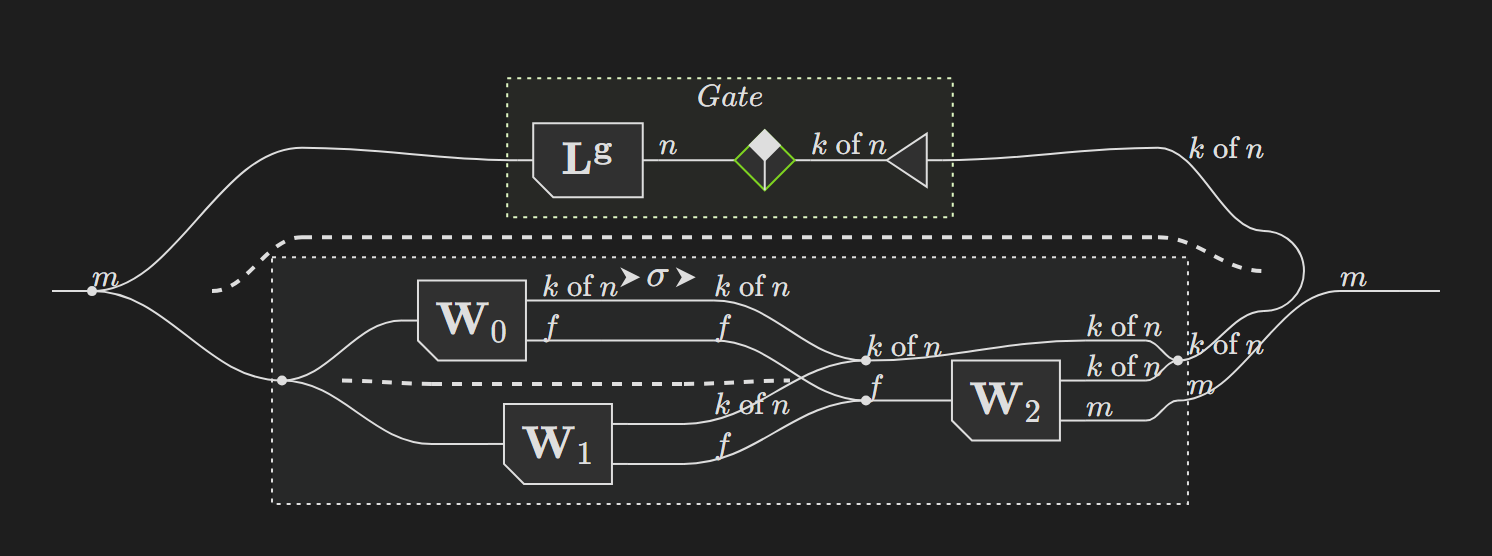

In [3]:
gate = standard_block(
    ops.Linear.template('m', 1, 'L^g')
    @ dst.TopK.template()
    @ ops.SoftMax.template(),
    '#DFF7C3', 'Gate')
expert_bank = standard_block(
    (0, 0)
    @ ((ops.Linear.template(1, 2, 'W_0') @ ops.Elementwise.template())
       * ops.Linear.template(1, 2, 'W_1'))
    @ ops.Einops.template('n f, n f -> n f')
    @ ops.Linear.template(1, 2, 'W_2')
    @ ops.Einops.template('k k m -> k m'),
    '#EDFCFF')
mixture_of_experts = (
    (0, 0)
    @ (gate * expert_bank)
    @ ops.Einops.template('n, n m -> m'))
recycled_mixture = h2m.recycle(mixture_of_experts)

read, = recycled_mixture.dom()
written, = recycled_mixture.cod()
assert len(read.shape()) == 1 and len(written.shape()) == 1, (
    'the sublayer reads one residual vector and returns one')
await notebook_diagrams.show_diagram(
    recycled_mixture,
    'The mixture of experts. The gate on the upper branch weights the experts on '
    'the lower one.',
    settings=DIAGRAMS)

## The mixture of experts, written out

The same sublayer with every weave and reindexing given by hand. A
`cat.Broadcasted` carries an operator, one weave per operand, one weave per
result and a reindexing per operand. A weave is a shape whose entries are
either an axis the operator reads or `WeaveMode.TILED`, which marks a position
the operator is broadcast over. The reindexing maps the tiled positions of the
result to the tiled positions of the operand, which is how one operator states
a transpose, a diagonal or a repetition.

`W_in` is broadcast over the selection `k` and reads the expert number as a
natural number, so the weight it uses is chosen per selected expert. `TopK`
returns the scores of the entries it kept and the numbers of those entries,
which is the pair the expert reads.

The same sublayer with each weave and reindexing written by hand.


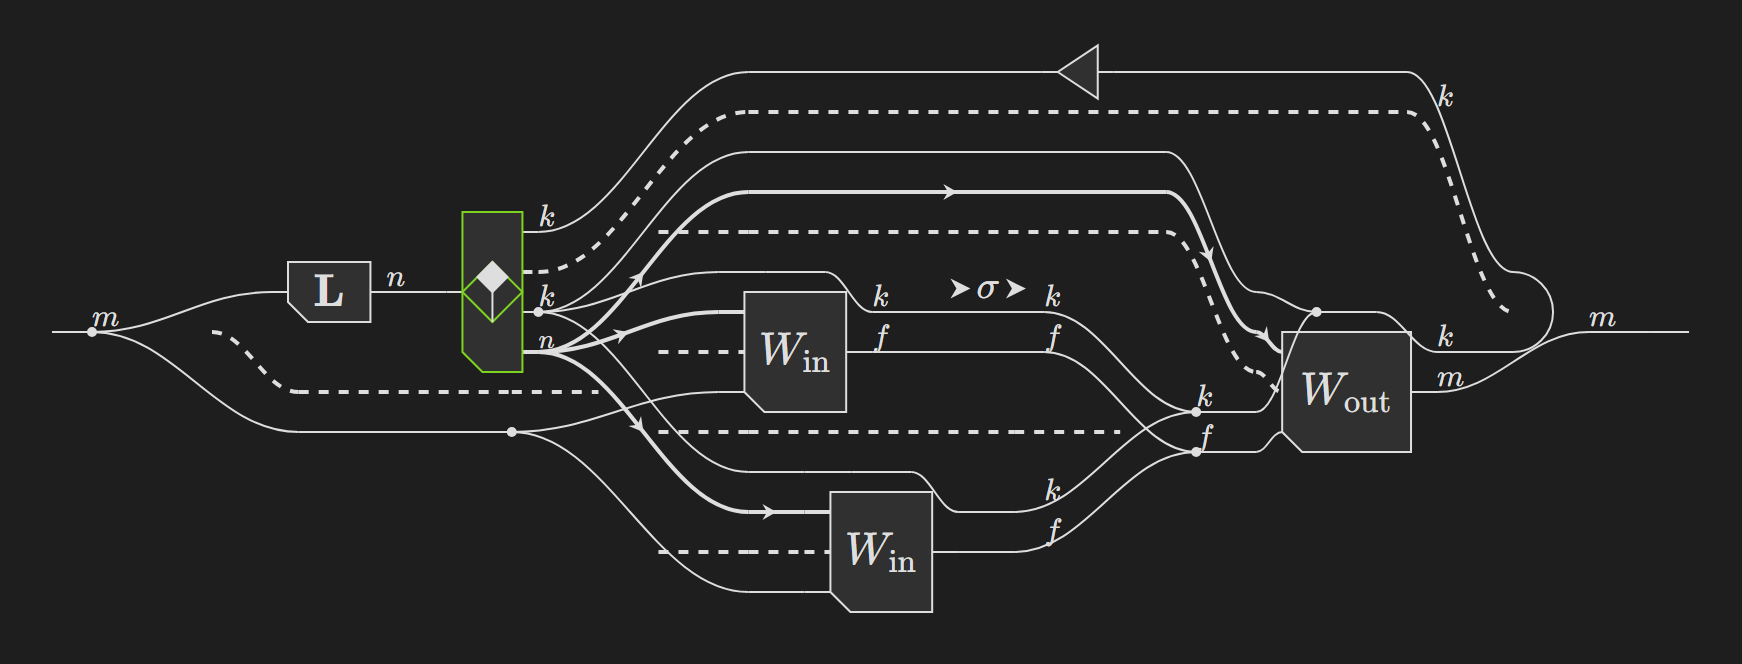

In [4]:
selection_axis = fd.DynamicName('k').capture(cat.RawAxis())
model_axis = fd.DynamicName('m').capture(cat.RawAxis())
hidden_axis = fd.DynamicName('f').capture(cat.RawAxis())
expert_count = fd.DynamicName('n').capture(nm.FreeNumeric())
expert_number = cat.Natural(expert_count)
expert_axis = fd.DynamicName('n').capture(cat.RawAxis(_size=expert_count))

W_in = cat.Broadcasted(
    operator=ops.Linear(fd.DynamicName('W', fd.DynamicName('\\text{in}'))),
    input_weaves=(
        cat.Weave(expert_number, (cat.WeaveMode.TILED,)),
        cat.Weave(cat.Reals(), (model_axis,)),
    ),
    output_weaves=(
        cat.Weave(cat.Reals(), (cat.WeaveMode.TILED, hidden_axis)),
    ),
    reindexings=(
        cat.Rearrangement((0,), (selection_axis,)),
        cat.Rearrangement((), (selection_axis,)),
    ))
selected_experts, token = W_in.dom()

W_out = cat.Broadcasted(
    operator=ops.Linear(fd.DynamicName('W', fd.DynamicName('\\text{out}'))),
    input_weaves=(
        cat.Weave(expert_number, ()),
        cat.Weave(cat.Reals(), (hidden_axis,)),
    ),
    output_weaves=(
        cat.Weave(cat.Reals(), (model_axis,)),
    ),
    reindexings=(
        cat.Rearrangement((), ()),
        cat.Rearrangement((), ()),
    ))

expert = (
    cat.Rearrangement((0, 0, 1, 0, 1), (selected_experts, token))
    @ (selected_experts
       * (((W_in @ ops.Elementwise.template()) * W_in)
          @ ops.Einops.template(',->')))
    @ W_out)
expert_gate = ops.Linear.template(1, expert_axis) @ cat.Broadcasted(
    operator=dst.TopK(),
    input_weaves=(
        cat.Weave(cat.Reals(), (expert_axis,)),
    ),
    output_weaves=(
        cat.Weave(cat.Reals(), (selection_axis,)),
        cat.Weave(expert_number, (selection_axis,)),
    ),
    reindexings=(
        cat.Rearrangement((), ()),
    )) @ ops.SoftMax.template(contracted=True)
written_out_mixture = h2m.recycle(
    (0, 0)
    @ (expert_gate * cat.Array(cat.Reals(), (model_axis,)))
    @ (cat.Array(cat.Reals(), (selection_axis,)) * expert)
    @ ops.Einops.template('k, k m -> m'))

assert len(written_out_mixture.dom()) == 1, (
    'the written-out sublayer reads one residual vector')
assert len(written_out_mixture.cod()[0].shape()) == 1, (
    'it returns one residual vector, as the signature form does')
await notebook_diagrams.show_diagram(
    written_out_mixture,
    'The same sublayer with each weave and reindexing written by hand.',
    settings=DIAGRAMS)

## The whole model

Multi-head latent attention reads the token through two routes. The rotary
route projects into complex numbers, multiplies by the rotation of the position
and reads the result back into reals. The real route compresses the token into
a latent of width $\ell$, normalises it and projects the key and the value out
of it. The two sets of scores are added before the softmax.

The first two layers use a dense perceptron, the remaining twenty-seven use the
mixture of experts, and each sublayer is wrapped in a normalisation and a
residual addition.

DeepSeek-V3. Each named operator draws its body beside the figure, so the model reads as its parts.

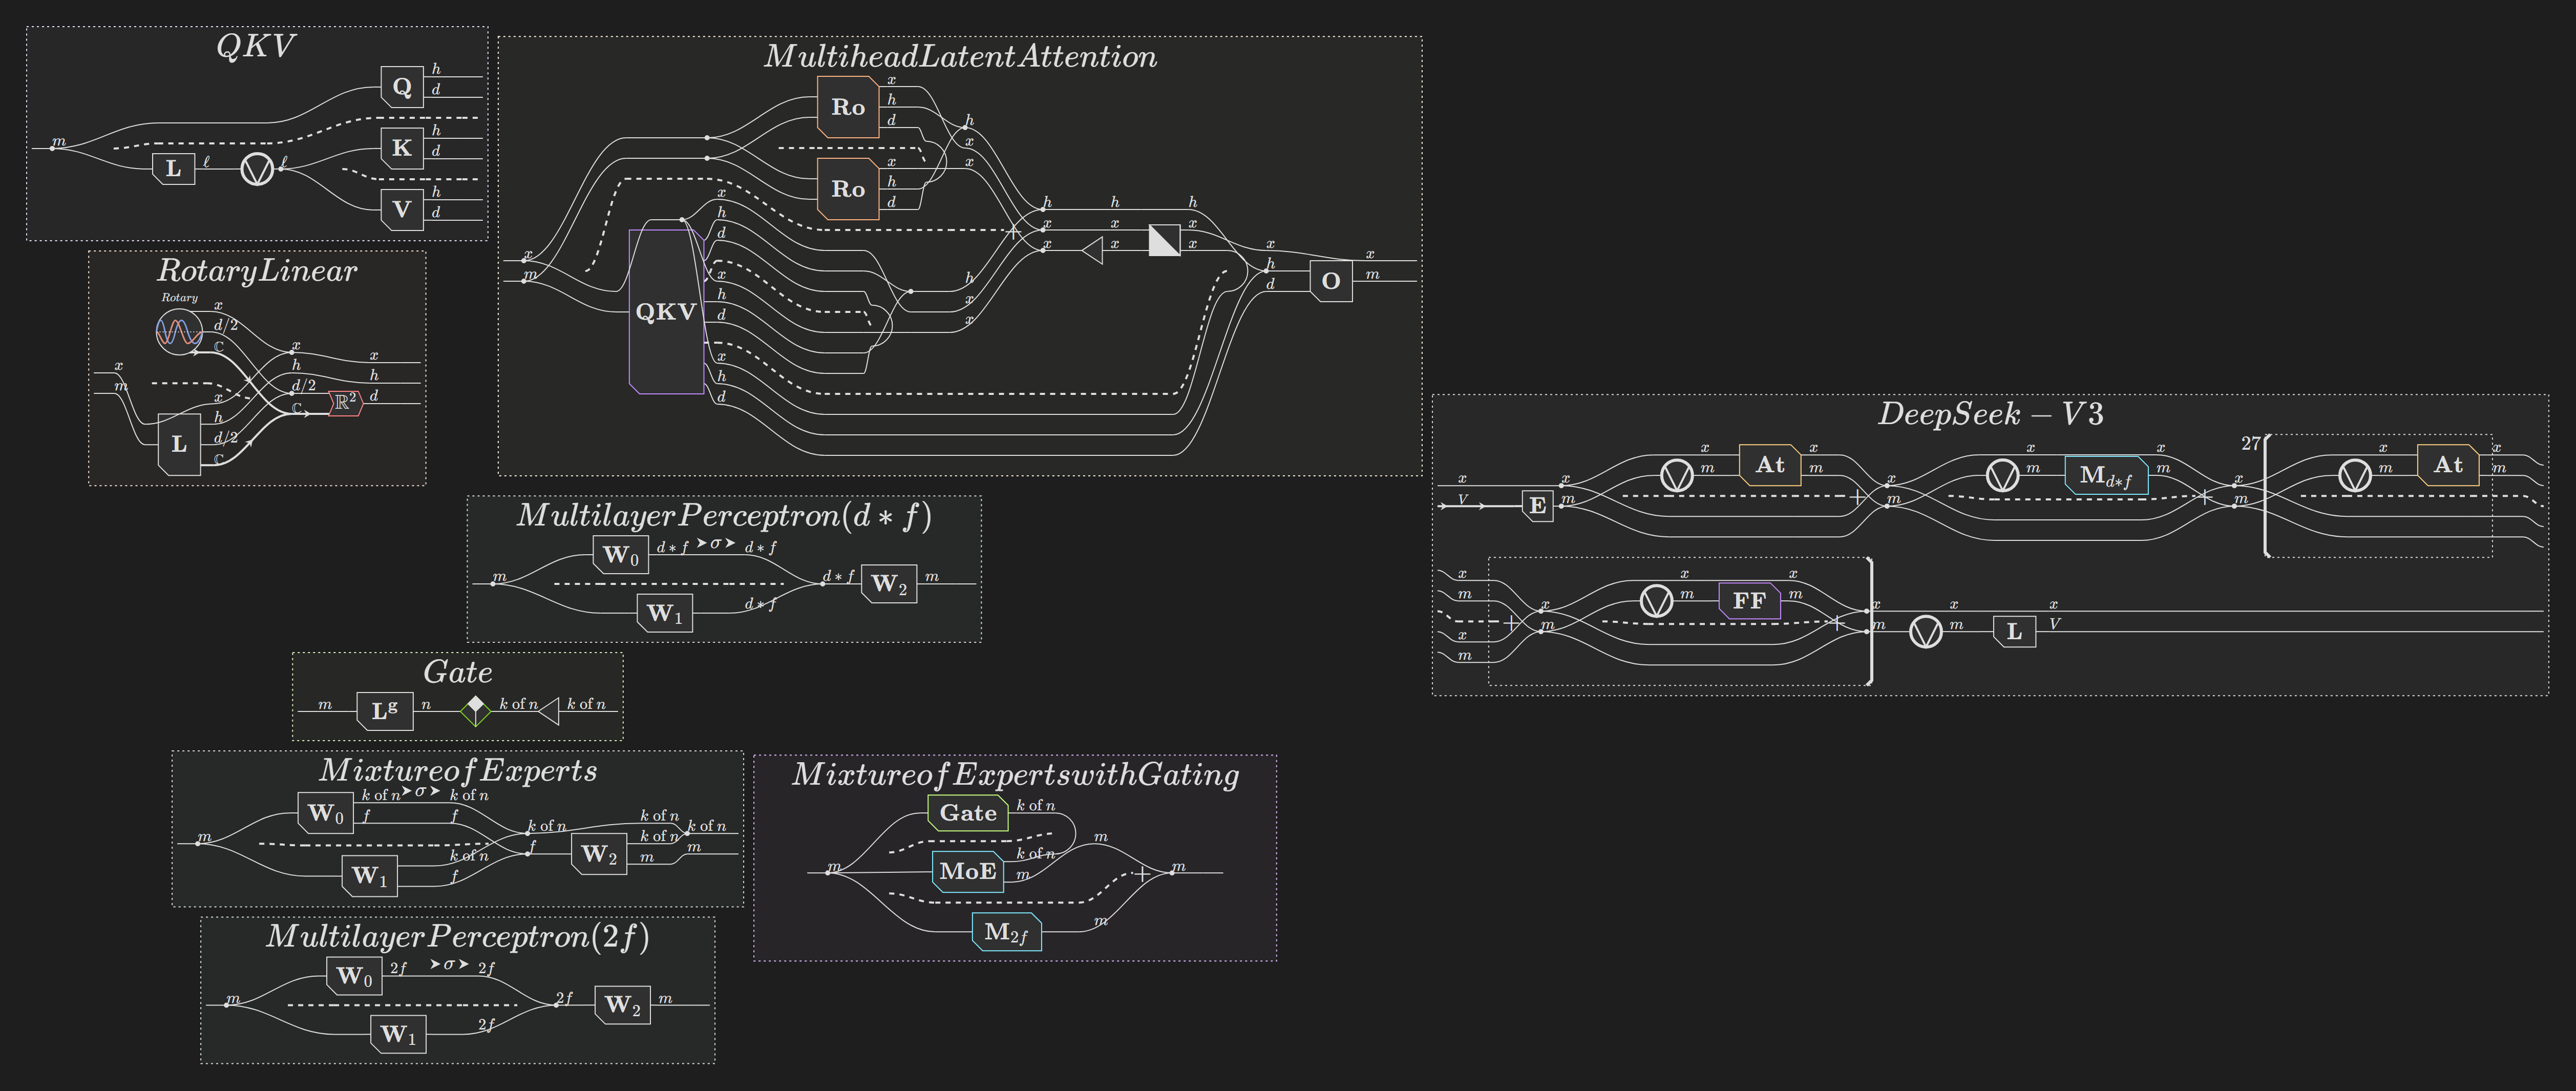

In [5]:
rotary_linear = hover_block(
    (dst.ComplexRotary().template()
     * (cat.RawAxis.named('x')
        >> ops.Linear.template(1, 2, output_datatype=dst.Complex())))
    @ ops.Einops.template('x d/2, x h d/2 -> x h d/2', datatype=dst.Complex())
    @ dst.Decomplex.template(),
    '#FFE4D2', 'Ro', title='Rotary Linear')
query_key_scores = ops.Einops.template('q h d, x h d -> h q x')
rotary_scores = (0, 0) @ (rotary_linear * rotary_linear) @ query_key_scores
latent_projections = hover_block(
    (0, 0)
    @ (ops.Linear.template(1, 2, 'Q')
       * (ops.Linear.template(1, '\\ell', 'L')
          @ ops.Normalize.template()
          @ (0, 0)
          @ (ops.Linear.template(1, 2, 'K') * ops.Linear.template(1, 2, 'V')))),
    '#EFE1FF', 'QKV')
multihead_latent_attention = hover_block(
    (0, 0)
    @ (rotary_scores * (latent_projections @ query_key_scores))
    @ ops.AdditionOp.template()
    @ ops.SoftMax.template()
    @ ops.WeightedTriangularLower.template()
    @ ops.Einops.template('h q x, x h d -> q h d')
    @ ops.Linear.template(2, 1, 'O'),
    '#FFF4E2', 'At', 'Multihead Latent Attention')


def multilayer_perceptron(inner_axis_name: str) -> cat.BroadcastedCategory:
    return hover_block(
        (0, 0)
        @ ((ops.Linear.template(name='W_0') @ ops.Elementwise.template())
           * ops.Linear.template(name='W_1'))
        @ ops.Einops.template('2f, 2f -> 2f')
        @ ops.Linear.template(inner_axis_name, name='W_2'),
        '#EDFCFF', f'M_{{{inner_axis_name}}}',
        title=f'Multilayer Perceptron ({inner_axis_name})')


routing_gate = hover_block(
    ops.Linear.template(1, 1, 'L^g')
    @ dst.TopK.template()
    @ ops.SoftMax.template(),
    '#DFF7C3', 'Gate')
routed_experts = hover_block(
    (0, 0)
    @ ((ops.Linear.template(1, 2, 'W_0') @ ops.Elementwise.template())
       * ops.Linear.template(1, 2, 'W_1'))
    @ ops.Einops.template('n f, n f -> n f')
    @ ops.Linear.template(1, 2, 'W_2')
    @ ops.Einops.template('k k m -> k m'),
    '#EDFCFF', 'MoE', 'Mixture of Experts')
gated_mixture = hover_block(
    (0, 0)
    @ (((0, 0) @ (routing_gate * routed_experts)
        @ ops.Einops.template('n, n m -> m'))
       * multilayer_perceptron('2f'))
    @ ops.AdditionOp.template(),
    '#DDBBFF', 'FF', 'Mixture of Experts with Gating')


def normalised_residual[B: cat.Datatype, A: cat.Axis](
    target: cat.BroadcastedCategory[B, A],
) -> cat.BroadcastedCategory[B, A]:
    return ((0, 0) @ ops.Normalize.template() @ target
            @ ops.AdditionOp.template())


repeated_layer = (normalised_residual(multihead_latent_attention)
                  @ normalised_residual(gated_mixture))
deepseek_model = standard_block(
    ops.Embedding.template('V', 1)
    @ normalised_residual(multihead_latent_attention)
    @ normalised_residual(multilayer_perceptron('d*f'))
    @ cat.Block(
        body=repeated_layer,
        block_tag=cat.BlockTag(
            repetition=nm.Integer(27),
            aesthetics=cat.BlockAesthetics(fill_color='#FFFFFF')))
    @ ops.Normalize.template()
    @ ops.Linear.template(1, 'V'),
    '#FFFFFF', 'DeepSeek', 'DeepSeek-V3')
recycled_model = h2m.recycle(deepseek_model)

indices, = recycled_model.dom()
logits, = recycled_model.cod()
assert isinstance(indices.datatype, cat.Natural), (
    'the model reads token indices, which are natural numbers')
assert len(logits.shape()) == 2, (
    'the model writes one array of positions by vocabulary entries')
await notebook_diagrams.show_diagram(
    recycled_model,
    'DeepSeek-V3. Each named operator draws its body beside the figure, so the '
    'model reads as its parts.',
    settings=DIAGRAMS)

## The free axis sizes

A configuration collects every symbol the expression leaves free, which is
every size a deployment of this architecture has to choose, together with the
epsilon of the normalisation. Nothing in the expression fixes them, so one
expression stands for every model of this shape.

In [6]:
config = generate_config.NumericConfig.template(recycled_model)
print(display_config.display_config(config))

assert {term.uid._name.to_bodies() for term in config.terms} == {
    '2f', 'V', '\\ell', '\\epsilon', 'd', 'd*f', 'd/2', 'f', 'h', 'k', 'm', 'n', 'x',
}, 'the free symbols are the sizes a deployment chooses, and the epsilon'

Name      |Type       |Bucket  |Assignment
V         |FreeNumeric|        |          
m         |FreeNumeric|        |          
x         |FreeNumeric|        |          
\epsilon  |FreeNumeric|        |          
\ell      |FreeNumeric|        |          
h         |FreeNumeric|        |          
d         |FreeNumeric|        |          
d         |FreeNumeric|        |          
d/2       |FreeNumeric|        |          
d*f       |FreeNumeric|        |          
n         |FreeNumeric|        |          
k         |FreeNumeric|        |          
f         |FreeNumeric|        |          
2f        |FreeNumeric|        |          
V         |FreeNumeric|        |          
